<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/Word_Embeddings_Assignment_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 24ADI306 Deep Learning - Self Learning Assignment (CO3)
## Exploring Word Representations: From Traditional Embeddings to Transformers

**Name / Roll No:** _fill in_  **Dataset:** text8 (cleaned Wikipedia text, ~17M tokens) via `gensim.downloader`

| Part | Content |
|---|---|
| 1 | Traditional: One-Hot, BoW, N-grams, TF-IDF |
| 2 | Matrix-based: Co-occurrence / SVD / LSA |
| 3 | Keras Embedding layer |
| 4 | Word2Vec (Skip-gram and CBOW) |
| 5 | FastText (out-of-vocabulary handling) and GloVe |
| 6 | Contextual embeddings: BERT, SBERT |
| 7 | Visualisation: PCA, t-SNE, UMAP, TensorFlow Embedding Projector |
| 8 | Comparative analysis |

Run on Colab: Runtime > Run all (CPU is enough; GPU speeds up BERT slightly).

In [1]:
!pip install -q "smart_open<6.0.0" gensim transformers sentence-transformers umap-learn scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 75.5 MB/s eta 0:00:00


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, random, re, time
from sklearn.metrics.pairwise import cosine_similarity
SEED = 42
random.seed(SEED); np.random.seed(SEED)

## 0. Dataset
We use **text8** (first 17M words of cleaned Wikipedia). It comes pre-tokenised in chunks of 10,000 tokens. We treat each chunk as one *document* for TF-IDF and as one *sentence* for Word2Vec/FastText.

In [3]:
# Compatibility patch: gensim.downloader expects the legacy smart_open API (needed on Python 3.13)
import sys, os, smart_open
smart_open.smart_open = smart_open.open
sys.modules['smart_open.smart_open'] = smart_open

import gensim.downloader as api
from gensim.models import Word2Vec, FastText
text8 = api.load('text8')
sentences = [list(s) for s in text8]

N_WORKERS = os.cpu_count() or 2
# Colab CPUs are slow, so we train on subsets to keep every cell under ~5 minutes
W2V_DOCS = 800   # ~8M tokens for Word2Vec
FT_DOCS  = 300   # ~3M tokens for FastText (subword models are much slower)
print('CPU workers:', N_WORKERS)
print('documents:', len(sentences), '| tokens:', sum(len(s) for s in sentences))
print(sentences[0][:20])

[==================================================] 100.0% 31.6/31.6MB downloaded
CPU workers: 2
documents: 1701 | tokens: 17005207
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


## 1. Traditional text representation
Toy corpus first, so the matrices are readable.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
toy = ["the king rules the kingdom",
       "the queen rules the kingdom",
       "the dog chased the cat",
       "a cat sat on the mat"]

# One-hot (word level): one vector per word, length = |V|
vocab = sorted({w for s in toy for w in s.split()})
w2i = {w:i for i,w in enumerate(vocab)}
one_hot = lambda w: np.eye(len(vocab))[w2i[w]]
print('Vocabulary:', vocab)
print('one-hot(king) :', one_hot('king'))
print('one-hot(queen):', one_hot('queen'))
print('cosine(king, queen) =', cosine_similarity([one_hot('king')],[one_hot('queen')])[0,0], ' <- always 0: no similarity information')

Vocabulary: ['a', 'cat', 'chased', 'dog', 'king', 'kingdom', 'mat', 'on', 'queen', 'rules', 'sat', 'the']
one-hot(king) : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
one-hot(queen): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
cosine(king, queen) = 0.0  <- always 0: no similarity information


In [ ]:
bow = CountVectorizer()
B = bow.fit_transform(toy)
print('Bag of Words'); display(pd.DataFrame(B.toarray(), columns=bow.get_feature_names_out()))

ng = CountVectorizer(ngram_range=(1,2))
G = ng.fit_transform(toy)
print('Unigram+Bigram features:', G.shape[1], '(vs', B.shape[1], 'unigrams) -> feature explosion')
print(ng.get_feature_names_out()[:15])

tf = TfidfVectorizer()
T = tf.fit_transform(toy)
print('TF-IDF'); display(pd.DataFrame(T.toarray().round(2), columns=tf.get_feature_names_out()))

**Observations (use in report):**
- One-hot: sparse, |V|-dimensional, every pair of words is orthogonal (no semantics).
- BoW: counts words per document; ignores order and meaning; common words dominate.
- N-grams: recover some local order but vocabulary grows very fast.
- TF-IDF: down-weights words that appear in many documents (e.g. "the"), but still sparse and has no semantic similarity between different words.

## 2. TF-IDF on the real corpus + Latent Semantic Analysis (SVD)
A word's vector here is its column in the TF-IDF document-term matrix (the word described by the documents it appears in). LSA compresses this with SVD.

In [5]:
docs = [' '.join(s) for s in sentences]
tfidf = TfidfVectorizer(min_df=5, max_features=20000, stop_words='english')
X = tfidf.fit_transform(docs)                 # (docs x terms)
terms = tfidf.get_feature_names_out()
t2i = {t:i for i,t in enumerate(terms)}
print('TF-IDF matrix:', X.shape, '| density: %.3f%%' % (100*X.nnz/np.prod(X.shape)))

from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=SEED)
lsa_vecs = svd.fit_transform(X.T)             # (terms x 100) -> dense LSA word vectors
print('LSA word vectors:', lsa_vecs.shape, '| explained variance: %.2f' % svd.explained_variance_ratio_.sum())

TF-IDF matrix: (1701, 20000) | density: 9.536%
LSA word vectors: (20000, 100) | explained variance: 0.28


In [6]:
def top_k_generic(word, k, vocab_index, matrix, index_to_word):
    if word not in vocab_index: return None
    sims = cosine_similarity(matrix[vocab_index[word]].reshape(1,-1), matrix).ravel()
    order = np.argsort(-sims)
    return [(index_to_word[i], round(float(sims[i]),3)) for i in order if index_to_word[i]!=word][:k]

tfidf_word_matrix = X.T.tocsr()
query_words = ['king','computer','music','war','city','science']

def tfidf_top5(w):  return top_k_generic(w, 5, t2i, tfidf_word_matrix, terms)
def lsa_top5(w):    return top_k_generic(w, 5, t2i, lsa_vecs, terms)

for w in query_words:
    print(f'\n[{w}]'); print('  TF-IDF:', tfidf_top5(w)); print('  LSA   :', lsa_top5(w))


[king]
  TF-IDF: [('son', 0.545), ('iii', 0.543), ('ii', 0.533), ('later', 0.494), ('seven', 0.474)]
  LSA   : [('iii', 0.865), ('son', 0.847), ('iv', 0.843), ('ii', 0.82), ('brother', 0.82)]

[computer]
  TF-IDF: [('computers', 0.75), ('computing', 0.523), ('hardware', 0.504), ('using', 0.476), ('programs', 0.464)]
  LSA   : [('computers', 0.926), ('machines', 0.873), ('hardware', 0.87), ('computing', 0.869), ('tasks', 0.816)]

[music]
  TF-IDF: [('musical', 0.612), ('musicians', 0.539), ('tunes', 0.499), ('genres', 0.488), ('performers', 0.487)]
  LSA   : [('musical', 0.927), ('tunes', 0.915), ('performers', 0.901), ('rhythmic', 0.892), ('rhythm', 0.89)]

[war]
  TF-IDF: [('troops', 0.665), ('united', 0.65), ('world', 0.636), ('states', 0.628), ('forces', 0.627)]
  LSA   : [('troops', 0.91), ('allied', 0.874), ('forces', 0.867), ('attacked', 0.865), ('soldiers', 0.861)]

[city]
  TF-IDF: [('area', 0.608), ('cities', 0.603), ('located', 0.597), ('largest', 0.578), ('mayor', 0.573)]
 

## 3. Neural embeddings with TensorFlow / Keras
The `Embedding` layer is a trainable lookup table of shape `(vocab_size, embedding_dim)`. We train it end-to-end on a **sentiment classification** task (IMDB) so the vectors become task-specific.

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB, MAXLEN, DIM = 10000, 200, 50
(x_tr,y_tr),(x_te,y_te) = imdb.load_data(num_words=VOCAB)
x_tr, x_te = pad_sequences(x_tr, maxlen=MAXLEN), pad_sequences(x_te, maxlen=MAXLEN)

kmodel = models.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(VOCAB, DIM, name='embedding'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')])
kmodel.compile('adam','binary_crossentropy',metrics=['accuracy'])
kmodel.summary()
hist = kmodel.fit(x_tr,y_tr,epochs=6,batch_size=128,validation_split=0.2,verbose=2)
print('Test accuracy:', kmodel.evaluate(x_te,y_te,verbose=0)[1])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,833 (1.91 MB)

 Trainable params: 500,833 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
157/157 - 3s - 17ms/step - accuracy: 0.6770 - loss: 0.6411 - val_accuracy: 0.7930 - val_loss: 0.5234
Epoch 2/6
157/157 - 2s - 15ms/step - accuracy: 0.8399 - loss: 0.4155 - val_accuracy: 0.8508 - val_loss: 0.3630
Epoch 3/6
157/157 - 2s - 11ms/step - accuracy: 0.8811 - loss: 0.3024 - val_accuracy: 0.8746 - val_loss: 0.3132
Epoch 4/6
157/157 - 3s - 19ms/step - accuracy: 0.9018 - loss: 0.2544 - val_accuracy: 0.8814 - val_loss: 0.2959
Epoch 5/6
157/157 - 2s - 11ms/step - accuracy: 0.9173 - loss: 0.2174 - val_accuracy: 0.8740 - val_loss: 0.3010
Epoch 6/6
157/157 - 2s - 12ms/step - accuracy: 0.9257 - loss: 0.1977 - val_accuracy: 0.8854 - val_loss: 0.2882
Test accuracy: 0.8777999877929688


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
great -> [('wonderful', 0.997), ('best', 0.996), ('beautiful', 0.996), ('fantastic', 0.995), ('brilliant', 0.995)]
awful -> [('worst', 0.999), ('waste', 0.999), ('dull', 0.999), ('save', 0.999), ('avoid', 0.999)]
boring -> [('worst', 0.999), ('poorly', 0.999), ('waste', 0.999), ('awful', 0.999), ('worse', 0.999)]
excellent -> [('7', 0.998), ('perfect', 0.998), ('8', 0.998), ('recommended', 0.998), ('9', 0.998)]


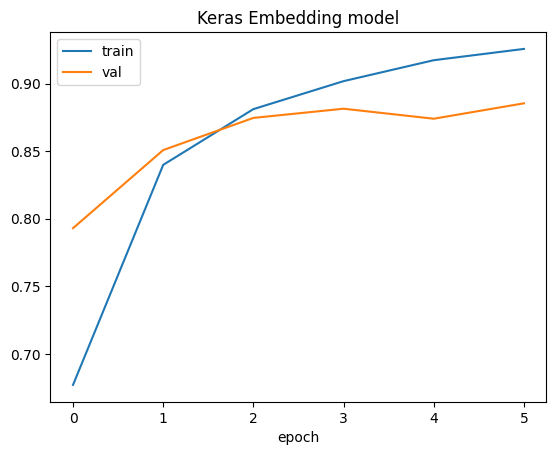

In [8]:
# Inspect learned embeddings
imdb_w2i = imdb.get_word_index()
idx2word = {v+3:k for k,v in imdb_w2i.items()}      # Keras IMDB offset of 3
keras_emb = kmodel.get_layer('embedding').get_weights()[0]
word2idx_k = {w:i for i,w in idx2word.items() if i < VOCAB}

def keras_top5(w):
    if w not in word2idx_k: return None
    sims = cosine_similarity(keras_emb[word2idx_k[w]].reshape(1,-1), keras_emb).ravel()
    return [(idx2word.get(i,'?'), round(float(sims[i]),3)) for i in np.argsort(-sims)[1:6] if i in idx2word]

for w in ['great','awful','boring','excellent']:
    print(w, '->', keras_top5(w))
plt.plot(hist.history['accuracy'],label='train'); plt.plot(hist.history['val_accuracy'],label='val')
plt.title('Keras Embedding model'); plt.xlabel('epoch'); plt.legend(); plt.show()

**Note:** neighbours from a sentiment task cluster by *polarity* (good/bad), not by general meaning, because the only training signal is the label. That is a key difference from Word2Vec.

## 4. Word2Vec: Skip-gram and CBOW
- **CBOW**: predict the centre word from its context (faster, better for frequent words).
- **Skip-gram**: predict context words from the centre word (slower, better for rare words).

In [10]:
t=time.time()
w2v_sg   = Word2Vec(sentences[:W2V_DOCS], vector_size=100, window=5, min_count=5, sg=1, workers=N_WORKERS, epochs=5, seed=SEED)
print('Skip-gram trained in %.0fs' % (time.time()-t)); t=time.time()
w2v_cbow = Word2Vec(sentences[:W2V_DOCS], vector_size=100, window=5, min_count=5, sg=0, workers=N_WORKERS, epochs=5, seed=SEED)
print('CBOW trained in %.0fs' % (time.time()-t))
print('Vocabulary size:', len(w2v_sg.wv))

Skip-gram trained in 147s
CBOW trained in 44s
Vocabulary size: 47132


In [11]:
# Five most similar words (cosine similarity) for query words
rows=[]
for w in query_words:
    rows.append({'query':w,
                 'Skip-gram':', '.join(x for x,_ in w2v_sg.wv.most_similar(w, topn=5)),
                 'CBOW':     ', '.join(x for x,_ in w2v_cbow.wv.most_similar(w, topn=5))})
pd.set_option('display.max_colwidth',None); display(pd.DataFrame(rows))

,query,Skip-gram,CBOW
0,king,"consort, queen, macedon, kings, vii","emperor, throne, judah, queen, prince"
1,computer,"computers, hardware, computing, laptop, microcomputers","console, software, computing, computers, digital"
2,music,"musical, jazz, rap, electronica, hop","musical, dance, pop, jazz, style"
3,war,"wwii, ww, wars, interwar, wwi","wars, rebellion, wwii, liberties, occupation"
4,city,"town, metropolitan, suburbs, borough, detroit","town, area, athens, village, adelaide"
5,science,"humanities, fiction, bioethics, astrobiology, thrillers","psychology, ethics, sciences, philosophy, journal"


In [12]:
# Semantic relationships: analogies  a : b :: c : ?
def analogy(a,b,c,model=w2v_sg):
    return model.wv.most_similar(positive=[b,c], negative=[a], topn=3)
print('man:king :: woman:?   ->', analogy('man','king','woman'))
print('paris:france :: berlin:? ->', analogy('paris','france','berlin'))
print('good:better :: bad:?  ->', analogy('good','better','bad'))
print('similarity(king,queen) =', round(w2v_sg.wv.similarity('king','queen'),3),
      '| similarity(king,banana) =', round(w2v_sg.wv.similarity('king','banana'),3) if 'banana' in w2v_sg.wv else 'n/a')
print('odd one out:', w2v_sg.wv.doesnt_match(['paris','london','berlin','apple']))

man:king :: woman:?   -> [('consort', 0.6652888655662537), ('queen', 0.6533796787261963), ('daughter', 0.6422151923179626)]
paris:france :: berlin:? -> [('germany', 0.7850745320320129), ('austria', 0.7214913964271545), ('poland', 0.6656090021133423)]
good:better :: bad:?  -> [('worse', 0.6440353989601135), ('smarter', 0.6204056143760681), ('smoother', 0.6175416111946106)]
similarity(king,queen) = 0.723 | similarity(king,banana) = 0.128
odd one out: apple


## 5. FastText (subword embeddings) and GloVe
FastText represents a word as the sum of its character n-gram vectors, so it can build a vector for a word it never saw.

In [13]:
t=time.time()
ft = FastText(sentences[:FT_DOCS], vector_size=100, window=5, min_count=5, sg=0, min_n=3, max_n=6, workers=N_WORKERS, epochs=5, seed=SEED)
print('FastText trained in %.0fs' % (time.time()-t))
for w in query_words[:3]:
    print(w, '->', [x for x,_ in ft.wv.most_similar(w, topn=5)])

FastText trained in 63s
king -> ['kingship', 'kingsley', 'viking', 'peking', 'kingston']
computer -> ['microcomputer', 'compute', 'compiler', 'comp', 'programmer']
music -> ['musicals', 'musical', 'classics', 'lyrics', 'style']


In [14]:
# Out-of-vocabulary (OOV) test: words not in training vocabulary
oov_words = ['kingdoms', 'computerization', 'musicianship', 'unkingly', 'supercomputerish', 'sciencey']
rows=[]
for w in oov_words:
    in_w2v = w in w2v_sg.wv.key_to_index
    in_ft  = w in ft.wv.key_to_index
    try:
        w2v_sg.wv[w]; w2v_res = 'vector found'
    except KeyError:
        w2v_res = 'KeyError (no vector)'
    ft_res = ', '.join(x for x,_ in ft.wv.most_similar(w, topn=3))
    rows.append({'word':w,'in Word2Vec vocab':in_w2v,'in FastText vocab':in_ft,'Word2Vec':w2v_res,'FastText nearest (built from subwords)':ft_res})
pd.set_option('display.max_colwidth',None)
display(pd.DataFrame(rows))

,word,in Word2Vec vocab,in FastText vocab,Word2Vec,FastText nearest (built from subwords)
0,kingdoms,True,True,vector found,"kingdom, estates, dictates"
1,computerization,False,False,KeyError (no vector),"computation, application, comprehension"
2,musicianship,True,False,vector found,"musicians, songwriters, musician"
3,unkingly,False,False,KeyError (no vector),"unwittingly, convincingly, jokingly"
4,supercomputerish,False,False,KeyError (no vector),"compulsive, interstellar, compulsory"
5,sciencey,False,False,KeyError (no vector),"science, sci, pseudoscience"


In [ ]:
# Optional: pretrained GloVe (~130 MB download)
glove = api.load('glove-wiki-gigaword-100')
for w in ['king','computer','music']:
    print(w, '->', [x for x,_ in glove.most_similar(w, topn=5)])
print('GloVe analogy king-man+woman:', glove.most_similar(positive=['king','woman'], negative=['man'], topn=3))

## 6. Contextual embeddings: BERT and SBERT
Static models give **one vector per word type**. BERT gives **one vector per word occurrence**, computed from the whole sentence.

In [15]:
import torch
from transformers import AutoTokenizer, AutoModel
tok  = AutoTokenizer.from_pretrained('bert-base-uncased')
bert = AutoModel.from_pretrained('bert-base-uncased').eval()

def bert_word_vec(sentence, word, layer=-1):
    enc = tok(sentence, return_tensors='pt', return_offsets_mapping=True)
    offsets = enc.pop('offset_mapping')[0].tolist()
    start = sentence.lower().index(word); end = start+len(word)
    idx = [i for i,(s,e) in enumerate(offsets) if s>=start and e<=end and e>s]
    with torch.no_grad():
        hs = bert(**enc, output_hidden_states=True).hidden_states[layer][0]
    return hs[idx].mean(0).numpy()

sents = {
 'bank (river)':   ('He sat on the bank of the river and fished.', 'bank'),
 'bank (money)':   ('She deposited her salary at the bank yesterday.', 'bank'),
 'bank (loan)':    ('The bank approved the loan for the new house.', 'bank'),
 'apple (fruit)':  ('I ate a fresh apple for breakfast.', 'apple'),
 'apple (company)':('Apple released a new phone this autumn.', 'apple'),
}
V = {k: bert_word_vec(s,w) for k,(s,w) in sents.items()}
names = list(V)
M = cosine_similarity(np.vstack([V[n] for n in names]))
display(pd.DataFrame(M.round(3), index=names, columns=names))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,bank (river),bank (money),bank (loan),apple (fruit),apple (company)
bank (river),1.000,0.463,0.387,0.271,0.020
bank (money),0.463,1.000,0.809,0.307,0.092
bank (loan),0.387,0.809,1.000,0.294,0.180
apple (fruit),0.271,0.307,0.294,1.000,0.242
apple (company),0.020,0.092,0.180,0.242,1.000


In [16]:
# Compare with the static Word2Vec vector: bank has ONE vector regardless of context
print('Word2Vec has a single vector for "bank": nearest words ->', [x for x,_ in w2v_sg.wv.most_similar('bank',topn=8)])
print('BERT cos(bank river, bank money)  = %.3f' % cosine_similarity([V['bank (river)']],[V['bank (money)']])[0,0])
print('BERT cos(bank money, bank loan)   = %.3f' % cosine_similarity([V['bank (money)']],[V['bank (loan)']])[0,0])
print('Static model would give 1.000 for every pair of "bank" occurrences.')

Word2Vec has a single vector for "bank": nearest words -> ['monetary', 'banks', 'bundesbank', 'fund', 'ecb', 'undp', 'gaza', 'cemac']
BERT cos(bank river, bank money)  = 0.463
BERT cos(bank money, bank loan)   = 0.809
Static model would give 1.000 for every pair of "bank" occurrences.


In [17]:
# Sentence embeddings with SBERT
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('all-MiniLM-L6-v2')
ss = ['A man is playing a guitar.', 'Someone is strumming an instrument.',
      'The stock market fell sharply today.', 'Shares dropped on Wall Street.']
E = sbert.encode(ss)
display(pd.DataFrame(cosine_similarity(E).round(2), index=[s[:25] for s in ss], columns=[f's{i}' for i in range(4)]))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,s0,s1,s2,s3
A man is playing a guitar,1.00,0.59,-0.05,-0.10
Someone is strumming an i,0.59,1.00,-0.04,-0.07
The stock market fell sha,-0.05,-0.04,1.00,0.56
Shares dropped on Wall St,-0.10,-0.07,0.56,1.00


## 7. Embedding visualisation
We project 100-d Word2Vec vectors to 2-d with PCA, t-SNE and UMAP and look for semantic clusters.

62 words selected


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


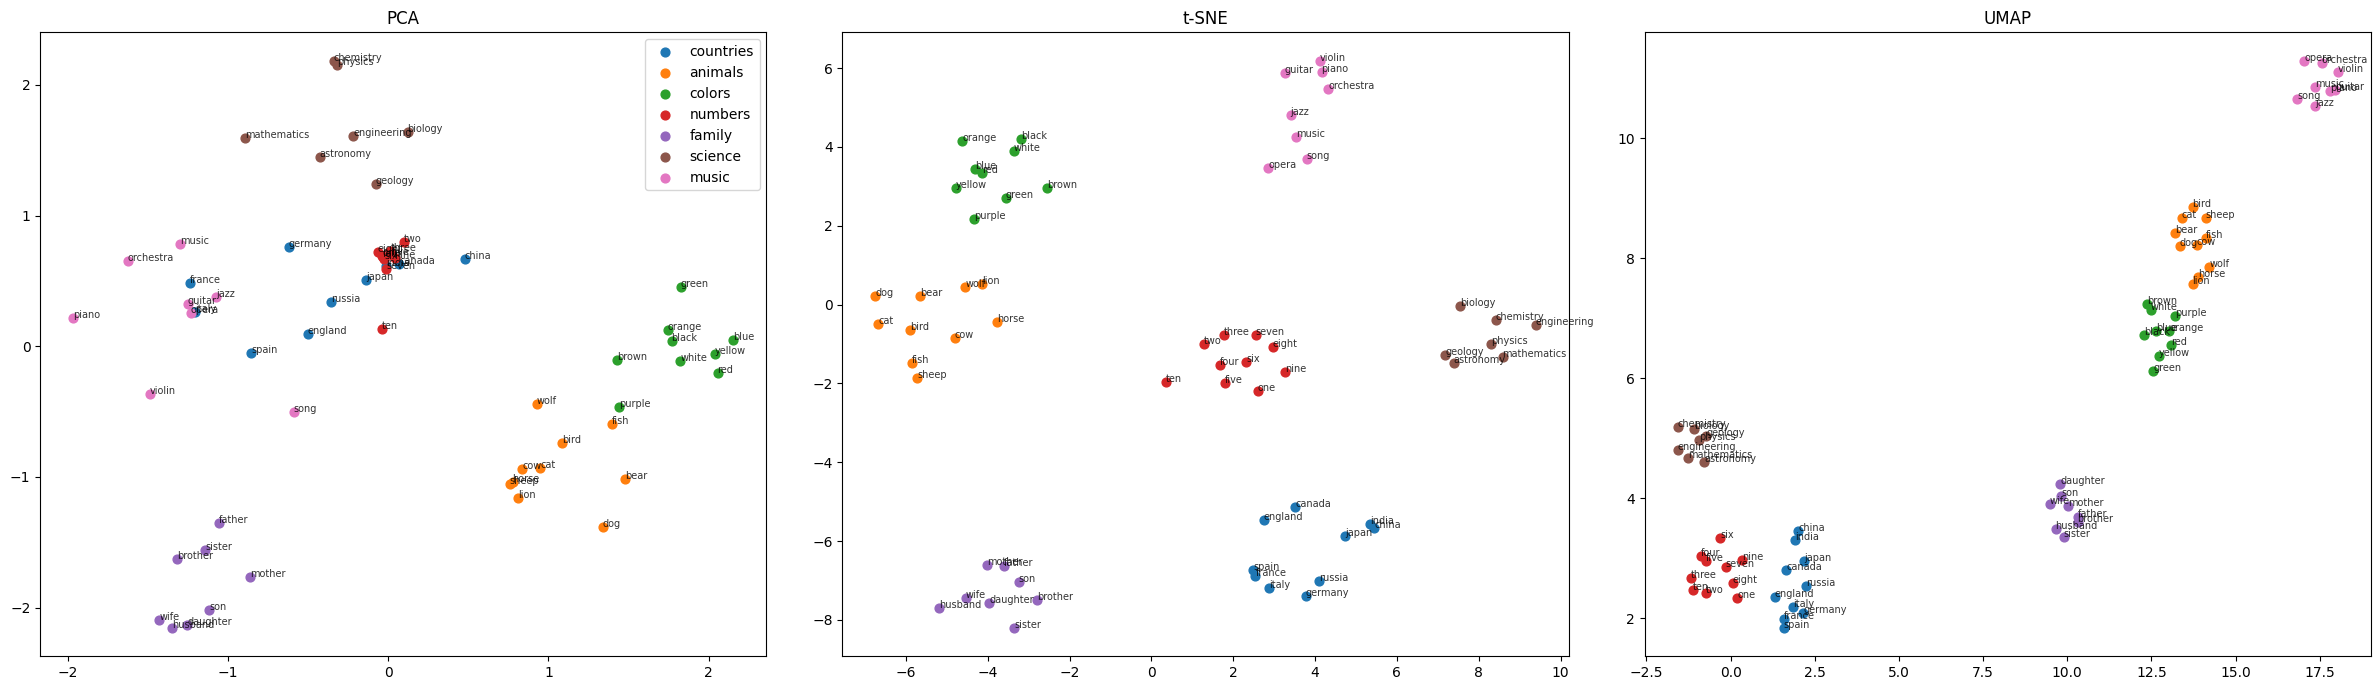

In [18]:
groups = {
 'countries': ['france','germany','italy','spain','china','japan','india','russia','england','canada'],
 'animals'  : ['dog','cat','horse','bird','fish','lion','cow','wolf','bear','sheep'],
 'colors'   : ['red','blue','green','yellow','black','white','orange','purple','brown'],
 'numbers'  : ['one','two','three','four','five','six','seven','eight','nine','ten'],
 'family'   : ['father','mother','son','daughter','brother','sister','wife','husband'],
 'science'  : ['physics','chemistry','biology','mathematics','astronomy','geology','engineering'],
 'music'    : ['music','jazz','piano','guitar','opera','song','orchestra','violin'],
}
words, labels = [], []
for g, ws in groups.items():
    for w in ws:
        if w in w2v_sg.wv: words.append(w); labels.append(g)
Wmat = np.vstack([w2v_sg.wv[w] for w in words])
print(len(words), 'words selected')
cmap = {g:c for g,c in zip(groups, plt.cm.tab10.colors)}

def scatter(ax, P, title):
    for g in groups:
        ix = [i for i,l in enumerate(labels) if l==g]
        ax.scatter(P[ix,0],P[ix,1],label=g,color=cmap[g],s=40)
    for i,w in enumerate(words): ax.annotate(w,(P[i,0],P[i,1]),fontsize=7,alpha=.8)
    ax.set_title(title)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
P_pca  = PCA(n_components=2, random_state=SEED).fit_transform(Wmat)
P_tsne = TSNE(n_components=2, perplexity=15, init='pca', random_state=SEED).fit_transform(Wmat)
P_umap = umap.UMAP(n_neighbors=10, min_dist=.3, random_state=SEED).fit_transform(Wmat)

fig, axes = plt.subplots(1,3,figsize=(24,7))
for ax,P,t in zip(axes,[P_pca,P_tsne,P_umap],['PCA','t-SNE','UMAP']): scatter(ax,P,t)
axes[0].legend(); plt.tight_layout(); plt.savefig('embeddings_2d.png',dpi=150); plt.show()

In [19]:
# Cosine-similarity heatmap, within-group vs between-group
S = cosine_similarity(Wmat)
same = np.array([[labels[i]==labels[j] and i!=j for j in range(len(words))] for i in range(len(words))])
print('Mean cosine within groups : %.3f' % S[same].mean())
print('Mean cosine between groups: %.3f' % S[~same & ~np.eye(len(words),dtype=bool)].mean())

Mean cosine within groups : 0.656
Mean cosine between groups: 0.230


In [20]:
# Export for TensorFlow Embedding Projector (https://projector.tensorflow.org)
# Load vectors.tsv and metadata.tsv via "Load" in the left panel.
top_words = w2v_sg.wv.index_to_key[:3000]
np.savetxt('vectors.tsv', np.vstack([w2v_sg.wv[w] for w in top_words]), delimiter='\t')
grp = {w:g for g,ws in groups.items() for w in ws}
with open('metadata.tsv','w',encoding='utf-8') as f:
    f.write('word\tgroup\n')
    for w in top_words: f.write(f'{w}\t{grp.get(w,"other")}\n')
print('Saved vectors.tsv and metadata.tsv ->', len(top_words), 'words')
try:
    from google.colab import files; files.download('vectors.tsv'); files.download('metadata.tsv'); files.download('embeddings_2d.png')
except Exception: pass

Saved vectors.tsv and metadata.tsv -> 3000 words


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Using the Embedding Projector:** open https://projector.tensorflow.org > *Load* > upload `vectors.tsv` (vectors) and `metadata.tsv` (metadata) > choose **PCA / t-SNE / UMAP** at the bottom-left > *Color by* `group` > type a word (e.g. `king`) in *Search* and tick "isolate points" to see its nearest neighbours by cosine distance. **Take screenshots for the report.**

## 8. Quantitative + qualitative comparison

In [23]:
# Quick quantitative check: WordSim-style intuition with word pairs (human-judged: high vs low relatedness)
pairs_high = [('king','queen'),('man','woman'),('car','automobile'),('dog','cat'),('music','song')]
pairs_low  = [('king','banana'),('car','philosophy'),('dog','algebra'),('music','tax'),('man','river')]
def pair_sim(model, a, b):
    try: return float(model.similarity(a,b))
    except KeyError: return np.nan
rows=[]

# Dynamically build models list depending on whether 'glove' is defined
models_to_test = [
    ('Word2Vec (SG)', w2v_sg.wv),
    ('Word2Vec (CBOW)', w2v_cbow.wv),
    ('FastText', ft.wv)
]
if 'glove' in globals():
    models_to_test.append(('GloVe', glove))
else:
    print("Warning: 'glove' model is not loaded. Run the GloVe download cell first to include it in the comparison.")

for name, kv in models_to_test:
    h = np.nanmean([pair_sim(kv,a,b) for a,b in pairs_high]); l = np.nanmean([pair_sim(kv,a,b) for a,b in pairs_low])
    rows.append({'model':name,'mean cos (related)':round(h,3),'mean cos (unrelated)':round(l,3),'gap':round(h-l,3)})
display(pd.DataFrame(rows))

,model,mean cos (related),mean cos (unrelated),gap
0,Word2Vec (SG),0.705,0.149,0.557
1,Word2Vec (CBOW),0.720,-0.114,0.834
2,FastText,0.625,0.031,0.594


In [24]:
comparison = pd.DataFrame([
 ['One-Hot',          'Sparse, |V|-d',      'None',                 'No',  'None',        'Very low', 'Orthogonal vectors, huge dimension'],
 ['Bag of Words',     'Sparse counts',      'None',                 'No',  'None',        'Very low', 'Ignores order and meaning'],
 ['TF-IDF',           'Sparse weighted',    'Very weak (co-occurrence by document)', 'No', 'None', 'Low', 'Sparse; synonyms not linked'],
 ['LSA (SVD)',        'Dense, 100-300d',    'Moderate (topical)',   'No',  'None',        'Medium (SVD on big matrix)', 'Linear; one vector per word'],
 ['Word2Vec',         'Dense, 100-300d',    'Good (analogies)',     'No',  'None (static)', 'Medium', 'Polysemy collapsed into one vector'],
 ['GloVe',            'Dense, 50-300d',     'Good (global stats)',  'No',  'None (static)', 'Medium (co-occurrence matrix)', 'Fixed vocabulary'],
 ['FastText',         'Dense, 100-300d',    'Good + morphology',    'Yes (subwords)', 'None (static)', 'Medium-High', 'Larger model, more memory'],
 ['Keras Embedding',  'Dense, task-specific','Task-dependent',      'No (needs <UNK>)', 'None (static)', 'Low-Medium', 'Needs labelled data; not general'],
 ['BERT / RoBERTa',   'Dense, 768d, per occurrence', 'Excellent', 'Yes (WordPiece)', 'Full sentence context', 'High (110M+ params)', 'Slow; needs GPU for scale'],
 ['SBERT / USE',      'Dense sentence vectors','Excellent (sentence level)','Yes (WordPiece)','Sentence context','High', 'Not word-level'],
], columns=['Technique','Representation','Semantic quality','OOV handling','Contextual','Compute cost','Main limitation'])
pd.set_option('display.max_colwidth',60); display(comparison)
comparison.to_csv('comparison_table.csv', index=False)

,Technique,Representation,Semantic quality,OOV handling,Contextual,Compute cost,Main limitation
0,One-Hot,"Sparse, |V|-d",None,No,None,Very low,"Orthogonal vectors, huge dimension"
1,Bag of Words,Sparse counts,None,No,None,Very low,Ignores order and meaning
2,TF-IDF,Sparse weighted,Very weak (co-occurrence by document),No,None,Low,Sparse; synonyms not linked
3,LSA (SVD),"Dense, 100-300d",Moderate (topical),No,None,Medium (SVD on big matrix),Linear; one vector per word
4,Word2Vec,"Dense, 100-300d",Good (analogies),No,None (static),Medium,Polysemy collapsed into one vector
5,GloVe,"Dense, 50-300d",Good (global stats),No,None (static),Medium (co-occurrence matrix),Fixed vocabulary
6,FastText,"Dense, 100-300d",Good + morphology,Yes (subwords),None (static),Medium-High,"Larger model, more memory"
7,Keras Embedding,"Dense, task-specific",Task-dependent,No (needs <UNK>),None (static),Low-Medium,Needs labelled data; not general
8,BERT / RoBERTa,"Dense, 768d, per occurrence",Excellent,Yes (WordPiece),Full sentence context,High (110M+ params),Slow; needs GPU for scale
9,SBERT / USE,Dense sentence vectors,Excellent (sentence level),Yes (WordPiece),Sentence context,High,Not word-level


## 9. Conclusions (rewrite in your own words in the report)
1. **Traditional** vectors are sparse and treat words as independent symbols; similarity only emerges from shared documents.
2. **Word2Vec/GloVe** learn dense vectors in which geometry encodes meaning (king - man + woman is close to queen), but give one vector per word, so polysemy ("bank") is merged.
3. **FastText** fixes OOV problems with character n-grams, useful for rare words, misspellings and morphologically rich languages.
4. **BERT** produces context-dependent vectors: the same word gets different vectors in different sentences, at the cost of much higher computation.
5. **Visualisation** (PCA preserves global variance; t-SNE/UMAP preserve local neighbourhoods) shows groups such as countries, numbers and colours forming clusters.